In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
from src.dataset import PropertyDataset
from src.model import ImageEncoder
import torch

tabular_cols = [
    "bedrooms", "bathrooms", "sqft_living",
    "sqft_lot", "grade", "lat", "long"
]

dataset = PropertyDataset(
    csv_path="../data/raw/train.csv",
    image_dir="../data/images",
    tabular_cols=tabular_cols,
    target_col="price"
)

image, tabular, target = dataset[0]

print(image.shape)
print(tabular.shape)
print(tabular)
print(target)

model = ImageEncoder()
embedding = model(image.unsqueeze(0))

print(embedding.shape)

[INFO] Dataset size after image filtering: 10
torch.Size([3, 224, 224])
torch.Size([7])
tensor([ 4.0000e+00,  2.2500e+00,  1.8100e+03,  9.2400e+03,  7.0000e+00,
         4.7436e+01, -1.2219e+02])
tensor(12.5011)
torch.Size([1, 512])


In [3]:
import sys, os
sys.path.append(os.path.abspath(".."))

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
from torch.utils.data import random_split

dataset = PropertyDataset(
    csv_path="../data/raw/train.csv",
    image_dir="../data/images",
    tabular_cols=tabular_cols,
    target_col="price"
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size]
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

[INFO] Dataset size after image filtering: 10


In [5]:
from src.model import MultimodalRegressor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultimodalRegressor(tabular_dim=len(tabular_cols)).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [6]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, tabular, targets in loader:
        images = images.to(device)
        tabular = tabular.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        preds = model(images, tabular)
        loss = criterion(preds, targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [7]:
for epoch in range(20):
    loss = train_one_epoch(model, train_loader)
    print(f"Epoch {epoch+1} | MSE Loss: {loss:.4f}")

Epoch 1 | MSE Loss: 186.6700
Epoch 2 | MSE Loss: 62.7220
Epoch 3 | MSE Loss: 44.4486
Epoch 4 | MSE Loss: 52.9311
Epoch 5 | MSE Loss: 42.5441
Epoch 6 | MSE Loss: 27.9889
Epoch 7 | MSE Loss: 29.2575
Epoch 8 | MSE Loss: 35.1741
Epoch 9 | MSE Loss: 32.2054
Epoch 10 | MSE Loss: 22.5399
Epoch 11 | MSE Loss: 14.9924
Epoch 12 | MSE Loss: 19.6426
Epoch 13 | MSE Loss: 26.7696
Epoch 14 | MSE Loss: 26.2121
Epoch 15 | MSE Loss: 19.0010
Epoch 16 | MSE Loss: 11.4574
Epoch 17 | MSE Loss: 12.5408
Epoch 18 | MSE Loss: 18.0776
Epoch 19 | MSE Loss: 19.1959
Epoch 20 | MSE Loss: 14.9940


In [8]:
import numpy as np
model.eval()

y_true_log = []
y_pred_log = []

with torch.no_grad():
    for images, tabular, targets in val_loader:
        images = images.to(device)
        tabular = tabular.to(device)

        preds = model(images, tabular)

        y_true_log.extend(targets.cpu().numpy())
        y_pred_log.extend(preds.cpu().numpy())

y_true_log = np.array(y_true_log)
y_pred_log = np.array(y_pred_log)

from sklearn.metrics import mean_squared_error, r2_score

mse_log = mean_squared_error(y_true_log, y_pred_log)
rmse_log = np.sqrt(mse_log)
r2_log = r2_score(y_true_log, y_pred_log)

print("Log-RMSE:", rmse_log)
print("Log-R²:", r2_log)

Log-RMSE: 3.1970404171028033
Log-R²: -139.73910522460938


In [9]:
gradients = None
activations = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer = model.image_encoder.features[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

In [10]:
for param in model.image_encoder.features.parameters():
    param.requires_grad = True

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def generate_gradcam(model, image, tabular):
    global gradients, activations

    model.eval()
    gradients = None
    activations = None

    image = image.unsqueeze(0).to(device)
    tabular = tabular.unsqueeze(0).to(device)

    with torch.enable_grad():
        output = model(image, tabular)
        score = output.squeeze()

        model.zero_grad()
        score.backward()

    weights = gradients.mean(dim=(2, 3), keepdim=True)
    cam = (weights * activations).sum(dim=1)

    cam = cam.squeeze().detach().cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    return cam


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def overlay_gradcam(image, cam, alpha=0.4):
    """
    image: torch.Tensor of shape (3, 224, 224)
    cam: numpy array of shape (7, 7)
    """
    img = image.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    cam = np.kron(cam, np.ones((32, 32)))
    cam = cam[:224, :224]
    heatmap = plt.cm.jet(cam)[:, :, :3]
    overlay = (1 - alpha) * img + alpha * heatmap

    return overlay


/Users/vedparikh/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


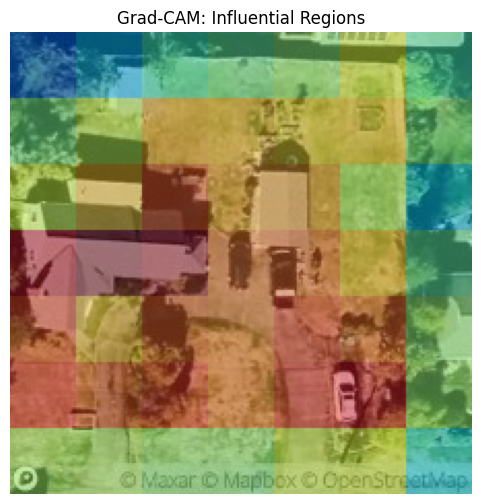

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Get sample
image, tabular, target = val_dataset[0]
cam = generate_gradcam(model, image, tabular)

# Convert image to numpy
img = image.permute(1, 2, 0).cpu().numpy()
img = (img - img.min()) / (img.max() - img.min())

# Upscale CAM (7x7 → 224x224)
cam_up = np.kron(cam, np.ones((32, 32)))
cam_up = cam_up[:224, :224]

# Apply colormap
heatmap = plt.cm.jet(cam_up)[:, :, :3]

# Overlay
overlay = 0.6 * img + 0.4 * heatmap

plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM: Influential Regions")
plt.show()

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

train_df = pd.read_csv("../data/raw/train.csv")

X_train = train_df[tabular_cols]
y_train = train_df["price"]

tabular_model = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

tabular_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [15]:
import os
import torch
import pandas as pd
from PIL import Image
import numpy as np

model.eval()

test_df = pd.read_csv("../data/raw/test.csv")

for col in tabular_cols:
    test_df[col] = pd.to_numeric(test_df[col], errors="coerce")

test_df[tabular_cols] = test_df[tabular_cols].fillna(0.0)

final_predictions = []

for idx, row in test_df.iterrows():
    img_path = f"../data/images/{idx}.png"

    tabular_input = (
        row[tabular_cols]
        .astype(float)
        .values
        .reshape(1, -1)
    )

    # Case 1: image exists → multimodal
    if os.path.exists(img_path):
        image = Image.open(img_path).convert("RGB")
        image = dataset.transform(image).unsqueeze(0).to(device)

        tabular = torch.from_numpy(tabular_input).float().to(device)

        with torch.no_grad():
            pred = model(image, tabular)
            pred = torch.expm1(pred).item()

    # Case 2: image missing → tabular-only fallback
    else:
        pred = tabular_model.predict(tabular_input)[0]

    final_predictions.append(pred)


/Users/vedparikh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/vedparikh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/vedparikh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/vedparikh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/vedparikh/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Standar

In [16]:
submission = pd.DataFrame({
    "id": test_df.index,
    "predicted_price": final_predictions
})

submission.to_csv("24112080_final.csv", index=False)

submission.head()

,id,predicted_price
0,0,5.777544e+06
1,1,1.296790e+09
2,2,1.558958e+12
3,3,2.035013e+14
4,4,1.424709e+08


In [17]:
import pandas as pd

train_df = pd.read_csv("../data/raw/train.csv")

In [18]:
X = train_df[tabular_cols]
y = train_df["price"]

for col in tabular_cols:
    X[col] = pd.to_numeric(X[col], errors="coerce")

X = X.fillna(0.0)

/var/folders/hv/m560wcmn6qg0qwwmxw5lsyzc0000gn/T/ipykernel_3726/2842498340.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = pd.to_numeric(X[col], errors="coerce")


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

tabular_model = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

tabular_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [21]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

y_pred_tab = tabular_model.predict(X_val)
mse = mean_squared_error(y_val, y_pred_tab)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred_tab)

print("Tabular-only RMSE:", rmse)
print("Tabular-only R²:", r2)

Tabular-only RMSE: 145383.87484519975
Tabular-only R²: 0.831566617764266
